In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Anas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Anas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Data Science Process

> CRISP-DM CRoss Industry Standard Process for Data Mining

![alt](../assets/Screenshot%202026-06-25%20at%2012.20.14.png)

# Step 1: Business Understanding

# Step 2: Data Understanding

Python-Setup mit UV und den notwendigen Abhängigkeiten eingerichtet.

> pyproject.toml als Dokumentation für die genutzten Pakete

```toml
[project]
name = "dhbw-neuekonzepte-portfolio"
version = "0.1.0"
description = "Add your description here"
readme = "README.md"
requires-python = ">=3.12"
dependencies = [
    "ipykernel>=7.2.0",
    "polars>=1.40.1",
    "pandas>=2.0.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.13.0",
    "pyarrow>=14.0.0",
    "scikit-learn>=1.9.0",
    "nltk>=3.9.4",
]
```

### Datensatz - Emotion Detection from Text

**Datensatz:** https://www.kaggle.com/datasets/pashupatigupta/emotion-detection-from-text

**Autor:** Pashupati Gupta

Die Daten des Datensatzes sind ein öffentlicher Auszug aus einem größeren unveröffentlichten  Datensatz der Plattform data.world. Nach Angaben des Authors wurden die Emotionsklassen manuell annotiert.

## 2.1. Business Understanding

## 2.2. SMART-Ziele

### SMART Ziele

**Forschungsfrage:** Lassen sich die in kurzen Tweets ausgedrückten Emotionen mit klassischen Machine-Learning-Verfahren zuverlässig automatisch klassifizieren? Welches Modell liefert die beste Vorhersagequalität?

| | Begriff | Bedeutung |
|---|---|---|
| **S** | `⁠Spezifisch⁠` | Emotionen werden durch ML Verfahren klassifiziert. Das für die Klassifizierung am besten geeignete Modell wird hierzu gesucht. |
| **M** | `⁠Messbar` | Das beste Modell erzielt den höchsten F1-Score (macro). |
| **A** | `⁠Attraktiv ` | Durch die fachlich korrekte Anwendung der in der VL vermittelten Methoden wird das Verständniss von Data Science Methoden geschuhlt und verstanden.|
| **R** | `⁠Realistisch` | Der Datensatz sowie die ML-Verfahren sind in der VL-Unterlagen aufgelistet und erläutert. |
| **T** | ⁠`Terminiert`⁠ | Das Notebook wird bis zum 02.07.26 fertigestellt |

**Ziel:** ⁠Den gewählten Datensatz analysieren und nutzbar aufbereiten um die Modellvorhersagen zu ermöglichen.

## 3.1 Data Understanding

### Datensatz einlesen

In [2]:
df = pd.read_csv('../data/csv/tweet_emotion_dataset.csv')   # Datensatz in CSV Format einlesen
df = df.drop(columns=['tweet_id'])                          # Spalte 'tweet_id' entfernen
df.columns = ['emotion', 'content']                         # Spalten umbenennen

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
dtypes: str(2)
memory usage: 3.7 MB


In [3]:
df

,emotion,content
0,empty,@tiffanylue i know i was listenin to bad habi...
1,sadness,Layin n bed with a headache ughhhh...waitin o...
2,sadness,Funeral ceremony...gloomy friday...
3,enthusiasm,wants to hang out with friends SOON!
4,neutral,@dannycastillo We want to trade with someone w...
...,...,...
39995,neutral,@JohnLloydTaylor
39996,love,Happy Mothers Day All my love
39997,love,Happy Mother's Day to all the mommies out ther...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...


Der gewählte Datensatz enthält 40.000 Zeilen sowie 3 Spalten. Spalte 1 (tweet_id) wird nicht benötigt und wurde daher entfernt. Spalte 2 enhält die Emotionsklasse zu der in Spalte 3 enthaltenten Kurznachricht (content).

Der Datensatz ist aufgrund seiner Einfachheit (Nur 2 relevante Spalten mit String-Werten) intuitiv verständlich. 

In [4]:
df.describe()

,emotion,content
count,40000,40000
unique,13,39827
top,neutral,I just received a mothers day card from my lov...
freq,8638,14


### Visualisierung der Zielvariablen

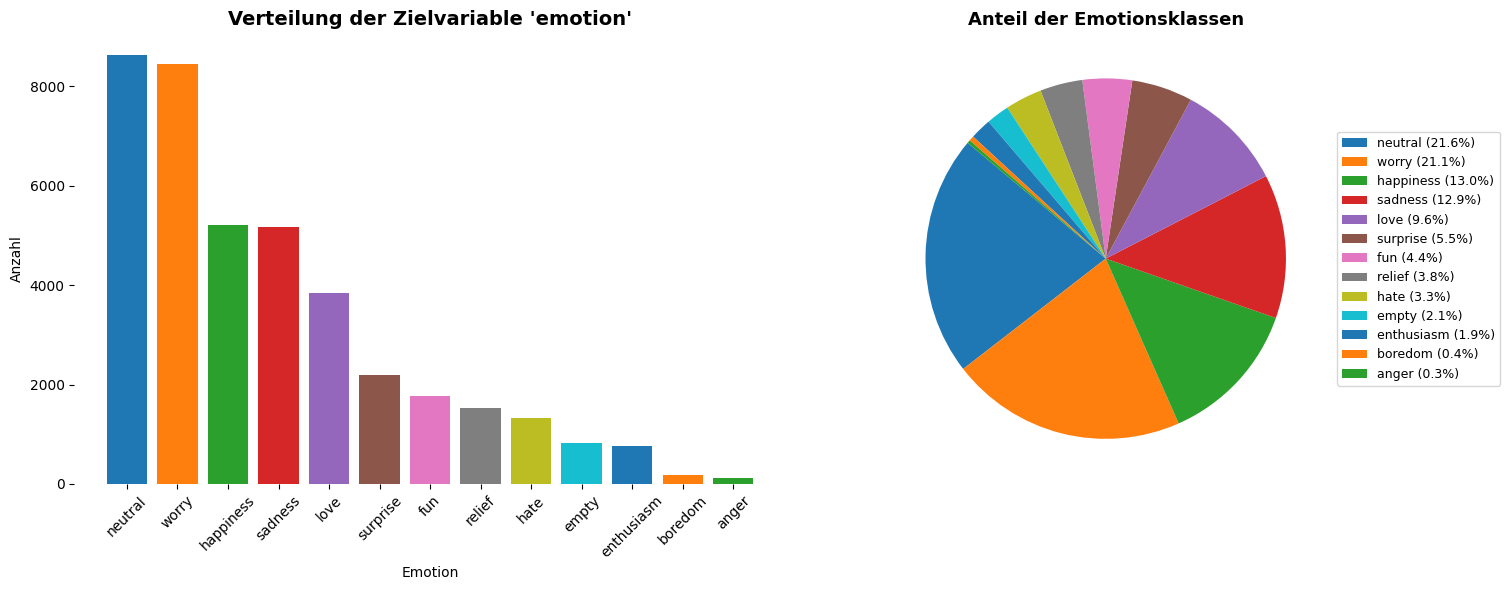

In [5]:
values = df["emotion"].value_counts()
labels = values.index
colors = plt.cm.tab10.colors

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

bars = ax_bar.bar(labels, values, color=colors[:len(labels)])
ax_bar.set_title("Verteilung der Zielvariable 'emotion'", fontsize=14, fontweight="bold")
ax_bar.set_xlabel("Emotion")
ax_bar.set_ylabel("Anzahl")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.spines[:].set_visible(False)

pct_labels = [f"{l} ({v/values.sum()*100:.1f}%)" for l, v in zip(labels, values)]
wedges, _ = ax_pie.pie(values, colors=colors[:len(labels)], startangle=140)
ax_pie.set_title("Anteil der Emotionsklassen", fontsize=13, fontweight="bold")
ax_pie.legend(wedges, pct_labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.tight_layout()
plt.show()

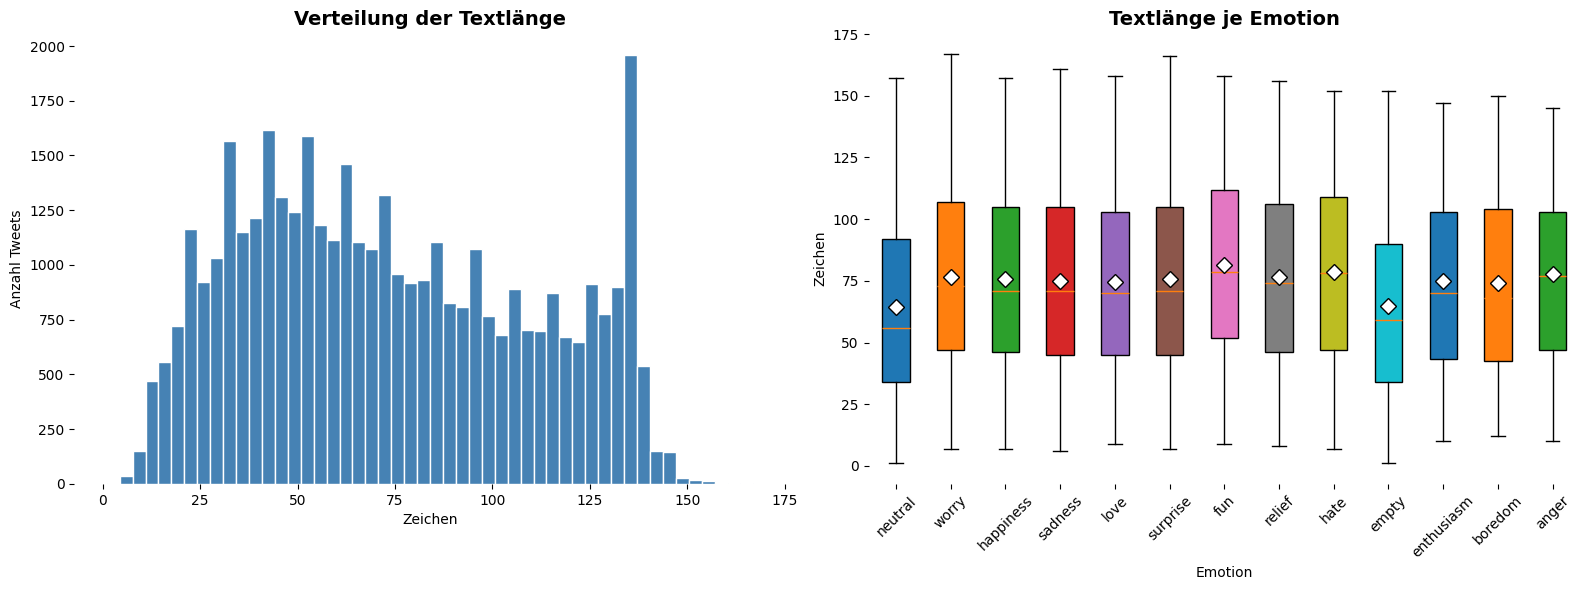

In [6]:
content_len = df.assign(text_length=df["content"].str.len())

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(16, 6))

ax_hist.hist(content_len["text_length"], bins=50, color="steelblue", edgecolor="white")
ax_hist.set_title("Verteilung der Textlänge", fontsize=14, fontweight="bold")
ax_hist.set_xlabel("Zeichen")
ax_hist.set_ylabel("Anzahl Tweets")
ax_hist.spines[:].set_visible(False)

data_per_emotion = [content_len[content_len["emotion"] == e]["text_length"].tolist() for e in labels]
bp = ax_box.boxplot(data_per_emotion, tick_labels=labels, patch_artist=True, showmeans=True, 
                    meanprops=dict(marker="D", markersize=8, markerfacecolor="white", markeredgecolor="black"))
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[i % len(colors)])
ax_box.set_title("Textlänge je Emotion", fontsize=14, fontweight="bold")
ax_box.set_xlabel("Emotion")
ax_box.set_ylabel("Zeichen")
ax_box.tick_params(axis="x", rotation=45)
ax_box.spines[:].set_visible(False)

plt.tight_layout()
plt.show()


- **Klassenungleichgewicht**: `neutral` (21,6 %) und `worry` (21,1 %) dominieren; `anger` hat nur 110 Einträge (0,3 %).
- Die **Textlänge** variiert kaum zwischen den Emotionsklassen und ist daher kein Merkmal der Emotion.
- Für das spätere Modell muss dieses Ungleichgewicht berücksichtigt

# Step 3: Data Preperation

## 3.4. Regex

| Schritt | Regex-Pattern | Beschreibung |
|---------|---------------|--------------|
| Kleinschreibung | `.lower()` | Vereinheitlichung Groß-/Kleinschreibung |
| URLs entfernen | `https?://\S+\|www\.\S+` | HTTP/HTTPS-Links und www-Adressen |
| Mentions entfernen | `@\w+` | Twitter-Nutzernamen wie `@user` |
| Hashtag-Symbol entfernen | `#` | Nur das `#`-Zeichen, das Wort bleibt erhalten |
| Sonderzeichen entfernen | `[^\w\s]` | Punkte, Kommas, Ausrufezeichen etc. |
| Zahlen entfernen | `\d+` | Reine Ziffernfolgen |
| Leerzeichen normalisieren | `\s+` → `' '` | Mehrfache Leerzeichen auf eines reduzieren |

Normalisierung, Skalierung und Standardisierung ist für unseren Datensatz nicht relevant, da es sich um textuelle Daten handelt, welche im folgenden sowieso durch Tokenisierung, Vektorisierung etc. weiterverarbeitet werden müssen. Eine verzeitige Normalisierung ist daher nicht notwendig. Normalisierung im Sinne von Lemmatisierung könnte angewendet werden.

In [7]:
token = df.content.str.lower()                                        # Text in Kleinbuchstaben umwandeln
token = token.str.replace(r'https?://\S+|www\.\S+', '', regex=True)   # Hyperlinks entfernen
token = token.str.replace(r'@\w+', '', regex=True)                    # Nutzererwähnungen entfernen
token = token.str.replace(r'[^\w\s]', '', regex=True)                 # Sonderzeichen entfernen
token = token.str.replace(r'\d+', '', regex=True)                     # Ziffern/Zahlen entfernen
token = token.str.replace(r'\s+', ' ', regex=True).str.strip()        # Doppelte Leerzeichen entfernen
df["token"] = token

## 4.1. Datenqualität

In [8]:
df.describe()

,emotion,content,token
count,40000,40000,40000
unique,13,39827,38998
top,neutral,I just received a mothers day card from my lov...,
freq,8638,14,99


### 4.1.1 Fehlende Werte

In [9]:
df.isna().sum()

emotion    0
content    0
token      0
dtype: int64

In [10]:
df.isnull().sum()

emotion    0
content    0
token      0
dtype: int64

Keine fehlende oder null Werte, die entfernt werden müssten...

In [11]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  40000 non-null  str  
 1   content  40000 non-null  str  
 2   token    40000 non-null  str  
dtypes: str(3)
memory usage: 6.3 MB


,emotion,content,token
340,empty,0,
659,neutral,@Joshuah_Pearson,
664,neutral,@emlevins,
2621,surprise,@swpave ?????????????,
3181,neutral,@Clumsyflic,
...,...,...,...
38650,neutral,@Britt_Uh_Knee,
39206,neutral,@hmigroupllc,
39415,neutral,0,
39518,neutral,@Remy_Foster,


ABER: 99 Nachrichten sind durch den Regex filter leer geworden, und werden im Folgenden entfernt:

In [12]:
df = df[df.token != ""]        # Zeilen mit leeren token entfernen

In [13]:
df.info()
df[df.token == ""]

<class 'pandas.DataFrame'>
Index: 39901 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39901 non-null  str  
 1   content  39901 non-null  str  
 2   token    39901 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,token


### 4.1.2 Duplikate

In [14]:
df[df.duplicated(subset="content", keep=False)]

,emotion,content,token
51,worry,why am i so tired?,why am i so tired
147,relief,I'm at work,im at work
324,sadness,I feel so deflated. No more doggy.,i feel so deflated no more doggy
366,worry,I feel so deflated. No more doggy.,i feel so deflated no more doggy
454,worry,Somebody please save the polar bears!,somebody please save the polar bears
...,...,...,...
39859,love,Happy Mothers Day,happy mothers day
39898,love,happy mothers day!,happy mothers day
39913,happiness,happy mother's day!,happy mothers day
39915,love,happy mother's day everyone,happy mothers day everyone


254 Nachrichten bzw. deren Tokenfolge sind Duplikate, welche im Folgenden entfernt werden:

In [15]:
df = df.drop_duplicates(subset="content", keep=False)    # Entfernen von Duplikaten

In [16]:
df.info()
df[df.content.duplicated(keep=False)]

<class 'pandas.DataFrame'>
Index: 39647 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  39647 non-null  str  
 1   content  39647 non-null  str  
 2   token    39647 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


,emotion,content,token


In [17]:
print(df.emotion.value_counts())
df.tail()

emotion
neutral       8514
worry         8416
happiness     5168
sadness       5139
love          3769
surprise      2175
fun           1774
relief        1516
hate          1322
empty          808
enthusiasm     757
boredom        179
anger          110
Name: count, dtype: int64


,emotion,content,token
39994,happiness,Succesfully following Tayla!!,succesfully following tayla
39996,love,Happy Mothers Day All my love,happy mothers day all my love
39997,love,Happy Mother's Day to all the mommies out ther...,happy mothers day to all the mommies out there...
39998,happiness,@niariley WASSUP BEAUTIFUL!!! FOLLOW ME!! PEE...,wassup beautiful follow me peep out my new hit...
39999,love,@mopedronin bullet train from tokyo the gf ...,bullet train from tokyo the gf and i have been...


### 4.1.4 Weitere Qualitätsprobleme

Der Datensatz enthält 13 Emotionsklassen, die sehr ungleich verteilt sind. Die fünf häufigsten Klassen (neutral, worry, happiness, sadness, love) machen zusammen bereits rund 76 % aller Tweets aus (30.464 von 38.998), während die übrigen acht Klassen nur sehr selten vorkommen: `anger`⁠ z.B. mit nur 110 Einträgen (0,3 %).

So wenige Beispiele reichen nicht, damit ein Modell diese seltenen Emotionen zuverlässig lernen kann. Das starke Klassenungleichgewicht würde die Vorhersagequalität verschlechtern und die Ergebnisse verzerren. Durch die Fokussierung auf die **Top-5-Klassen** erhalten wir ein ausgewogeneres und besser lernbares Klassifikationsproblem, ohne den Großteil der Daten zu verlieren.

**Die Top-5-Klassen:**

1. `Neutral, n=8514`
2. `Worry, n=8416`
3. `Happiness, n=5168`
4. `Sadness, n=5139`
5. `Love, n=3769`

Da diese fünf Klassen jedoch weiterhin unterschiedlich häufig vertreten sind, wird gleichmäßig auf **n=3.769** Einträge pro Klasse gesampelt. Dieser Wert entspricht der Größe der kleinsten der fünf Klassen. So enthält jede Klasse gleich viele Trainingsbeispiele, was ein verzerrungsfreies Lernen ermöglicht.


In [18]:
results = {}

In [19]:
# Filten des Datensatz auf auf Top 5 Emotionsklassen
keep = ["neutral", "worry", "happiness", "sadness", "love"]     
df_filtered = df[df.emotion.isin(keep)]

In [20]:
X_raw_train, X_raw_val, y_raw_train, y_raw_val = train_test_split(
    df_filtered["content"], df_filtered["emotion"], test_size=0.15, random_state=42
)

baseline_vec = CountVectorizer()
X_raw_train_vec = baseline_vec.fit_transform(X_raw_train)
X_raw_val_vec = baseline_vec.transform(X_raw_val)

baseline_classifiers = [
    ("Baseline KNN", KNeighborsClassifier()),
    ("Baseline DTC", DecisionTreeClassifier(random_state=42)),
    # RF/MLP auf dem riesigen ungefilterten Rohtext-Vokabular sind auf CPU sehr teuer.
    # Fuer den schnellen Baseline-Vergleich (Vorverarbeitung ja/nein) reichen KNN+DTC.
    # ("Baseline RFC", RandomForestClassifier(random_state=42)),
    # ("Baseline MLP", MLPClassifier(random_state=42, early_stopping=True)),
]

for name, classifier in baseline_classifiers:
    classifier.fit(X_raw_train_vec, y_raw_train)
    y_pred = classifier.predict(X_raw_val_vec)
    f1 = f1_score(y_raw_val, y_pred, average="macro")
    print(f"{name}: F1-Score (val): {f1:.3f}")
    results[name] = (f1, classifier, X_raw_train_vec, X_raw_val_vec, None)

Baseline KNN: F1-Score (val): 0.284


Baseline DTC: F1-Score (val): 0.343


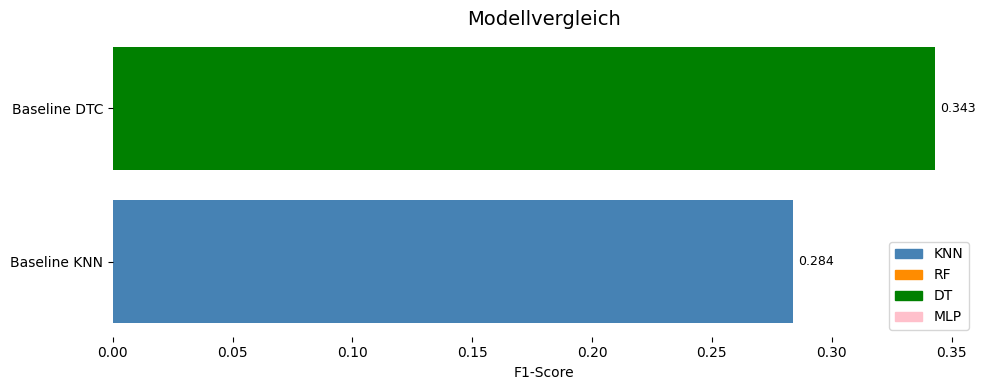

In [21]:
def plot_results(title="Modellvergleich"):
    results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
    color_map = {"KNN": "steelblue", "RF": "darkorange", "DT": "green", "MLP": "pink"}
    colors = [next(c for k, c in color_map.items() if k in name) for name in results_df.index]

    _, ax = plt.subplots(figsize=(10, max(4, len(results_df) * 0.4)))
    bars = ax.barh(results_df.index, results_df.values, color=colors)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("F1-Score")
    ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
    ax.spines[:].set_visible(False)
    ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc="lower right")
    plt.tight_layout()
    plt.show()

plot_results()

In [22]:
# Sampeln der übrigen Emotionsklassen auf gleiche Verteilung mit jeweils n=3769 Tweets
df_filtered = df_filtered.groupby("emotion").sample(n=3769, random_state=42).reset_index(drop=True)

print(f"Verbleibende Klassen: {keep}")
print(f"Anteil am Gesamtdatensatz: {len(df_filtered) / 40000 * 100:.1f}%")
print(f"Verbleibende Einträge: {len(df_filtered)}")
print(f"Gelöschte Einträge: {len(df) - len(df_filtered)}")

df = df_filtered

Verbleibende Klassen: ['neutral', 'worry', 'happiness', 'sadness', 'love']
Anteil am Gesamtdatensatz: 47.1%
Verbleibende Einträge: 18845
Gelöschte Einträge: 20802


In [23]:
print(df.emotion.value_counts())

emotion
happiness    3769
love         3769
neutral      3769
sadness      3769
worry        3769
Name: count, dtype: int64


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18845 entries, 0 to 18844
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  18845 non-null  str  
 1   content  18845 non-null  str  
 2   token    18845 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


In [25]:
df.describe

<bound method NDFrame.describe of          emotion                                            content  \
0      happiness  @R1CC1 that's funny...well, i'll say bye again...   
1      happiness  @Sarah_LeAnn if it makes you feel better im st...   
2      happiness           @JessicaCorban stellar! You 2 look great   
3      happiness      mrskutcher &amp; aplusk you two are to funny!   
4      happiness           regarde les tant attendues photographies   
...          ...                                                ...   
18840      worry  @DutchRaymond gay marriage isn't legal everywh...   
18841      worry  has spent the last two weeks attempting to gro...   
18842      worry  So lost  on my owm tryinh to find matter in th...   
18843      worry  @fletcherxx maxxie and anwar. ep 5? i think. i...   
18844      worry  Whats your name: Adelaide-Marie How old r u: 1...   

                                                   token  
0      thats funnywell ill say bye again bc im really.

## 5.1 Beschreibung des Korpus

Unser Korpus ist die Sammlung von Tweets in englischer Sprache. 

Die Tweets sind alle auf Englisch. Jeder Tweet ist ein eigener Eintrag mit einer zugeordneten Emotion. Nach der Bereinigung und der Beschränkung auf die fünf Klassen besteht unser Korpus aus 19.210 Tweets.

Der Text wird nachfolgend weiter optimiert: Stopwords wie „the", „and" oder „is" werden entfernt, Wörter auf ihren Wortstamm gekürzt (Lemmatisierung).

+ **Word Types:** 15.904
+ **Word Instances:** 115.313

## 5.2. Wortfrequenzanalyse

Whitespace Tokenisierung

In [26]:
df["token"] = df["token"].str.split()     # Whitespace Tokenisierung eigener Spalte

In [27]:
df.tail()

,emotion,content,token
18840,worry,@DutchRaymond gay marriage isn't legal everywh...,"[gay, marriage, isnt, legal, everywhere, here]"
18841,worry,has spent the last two weeks attempting to gro...,"[has, spent, the, last, two, weeks, attempting..."
18842,worry,So lost on my owm tryinh to find matter in th...,"[so, lost, on, my, owm, tryinh, to, find, matt..."
18843,worry,@fletcherxx maxxie and anwar. ep 5? i think. i...,"[maxxie, and, anwar, ep, i, think, i, am, up, ..."
18844,worry,Whats your name: Adelaide-Marie How old r u: 1...,"[whats, your, name, adelaidemarie, how, old, r..."


### 5.2.3 Barchart Visualisierung

Anzahl Token (insgesamt):  236268
Anzahl einzigartiger Token |V|: 20965


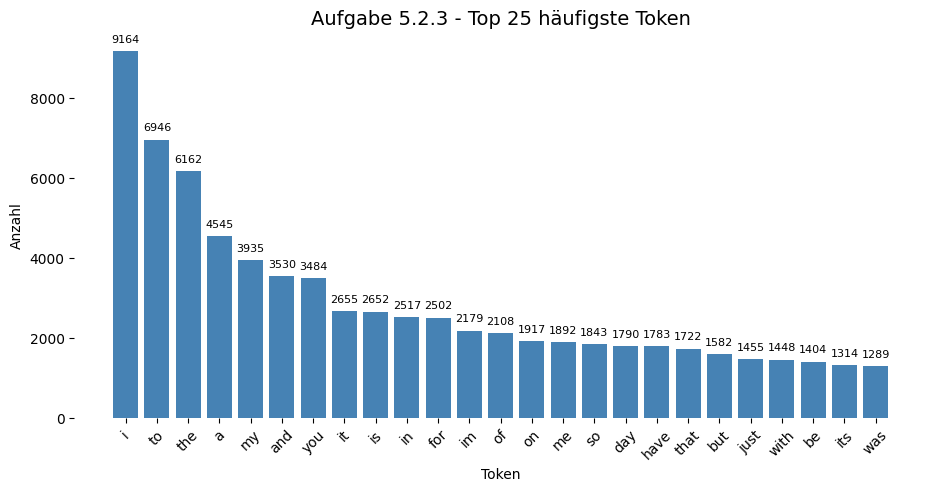

In [28]:
def plot_top_words(top_n=25):
    word_list = np.concatenate(df.token.values)

    word_counts = pd.Series(word_list).value_counts()
    word_counts = word_counts.reset_index()
    word_counts.columns = ["word", "count"]

    print("Anzahl Token (insgesamt): ", len(word_list))
    print("Anzahl einzigartiger Token |V|:", len(word_counts.word))

    top_words = word_counts.head(top_n)

    _, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(top_words["word"], top_words["count"], color="steelblue")
    ax.set_title(f"Aufgabe 5.2.3 - Top {top_n} häufigste Token", fontsize=14)
    ax.set_xlabel("Token")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[:].set_visible(False)
    _ = ax.bar_label(bars, padding=5, fontsize=8)
    plt.show()

plot_top_words()

Die Wortfrequenzanalyse zeigt, dass die häufigsten Wörter im Korpus wie „im", „day", „good" oder „go" haben keinen emotionalen oder inhaltlichen Mehrwert. Ihr hohes Aufkommen im gesamten Datensatz macht sie zu Stopwords, die im folgenden Schritt gefiltert werden sollten.

### 5.2.5 Stopwords entfernen

In [29]:
stop_words = set(stopwords.words("english"))

print("Anzahl von Stopwords: " + str(len(stop_words)))
print("Stopwords: " + str(stop_words))

Anzahl von Stopwords: 198
Stopwords: {'herself', 'those', "we're", 'between', 'because', "i'll", "it's", 'in', 'was', 'an', 'we', 'on', 'isn', 'mustn', 'below', 'into', "they've", 'the', 'too', "isn't", "wouldn't", 't', "don't", 'it', 'he', 'ma', "hasn't", 'll', 'so', "they're", 'other', 'not', 'their', 'to', 'just', 'now', 'has', 'of', 'be', 'if', 'your', "mustn't", 'wasn', 'most', 'same', 'whom', 'me', "aren't", "won't", 'once', 'themselves', 're', 'through', 'its', 'couldn', 'doing', 'shan', 'this', 'aren', "we've", "it'd", 'who', 'from', 'you', "you've", 'been', 'i', 'our', 'both', 'hers', 'y', 'theirs', "wasn't", 'all', 'what', 'out', 'can', 'until', "mightn't", 'but', 'she', 'than', "she's", 'ours', 've', 'am', 'after', 'as', 'is', "i've", 'while', "she'd", "hadn't", "it'll", 'will', "shan't", 'himself', 'about', "you'll", "weren't", 'nor', 'does', 'had', "needn't", 'being', 'that', 'where', "he's", 'm', 'needn', "you're", 'her', "they'll", 'weren', 'down', 'more', 'under', 'havi

In [30]:
df.token = df.token.apply(lambda t: [w for w in t if w not in stop_words])  # Stopwords entfernen

In [31]:
def top_words_all(n=30):
    return pd.DataFrame([{
        "emotion": emotion,
        "top_words": pd.Series(
            np.concatenate(df[df["emotion"] == emotion]["token"].values)
        ).value_counts().head(n).index.tolist()
    } for emotion in df["emotion"].unique()]).set_index("emotion")

top_words_all()

,top_words
emotion,
happiness,"[day, good, im, happy, great, lol, thanks, tod..."
love,"[love, day, happy, mothers, im, good, thanks, ..."
neutral,"[im, day, get, go, going, like, good, dont, wo..."
sadness,"[im, sad, miss, day, go, work, get, cant, like..."
worry,"[im, dont, get, cant, go, like, day, going, to..."


Standard-Stopwords wurden erfolgreich entfernt. Es bleiben jedoch weiterhin Wörter, die gleichermaßen häufig in allen Klassen auftreten (z. B. „im", „day", „go"). Diese werden im nächsten Schritt durch eine iterative Schleife zusätzlich entfernt.

In [32]:
# Iterativ klassenübergreifende Top30-Wörter entfernen, bis keine Schnittmenge mehr übrig bleibt

while True:
    common = set.intersection(*[set(w) for w in top_words_all().top_words])  # Schnittmenge der Top30-Wörter aller Klassen
    if not common:  # Stoppen, wenn keine Schnittmenge gefunden
        break
    df.token = df.token.apply(lambda t: [w for w in t if w not in common])
    print("Removed:", common)

Removed: {'one', 'day', 'today', 'know', 'good', 'get', 'go', 'time', 'like', 'im', 'got'}
Removed: {'really', 'see', 'u', 'amp', 'night', 'cant', 'going', 'much', 'well'}


Removed: {'lol', 'back', 'oh', 'home', 'dont'}
Removed: {'ill', 'think', 'work', 'want', 'new'}
Removed: {'love', 'thats', 'still'}


Removed: {'tomorrow', 'last'}
Removed: {'tonight'}


Anzahl Token (insgesamt):  111784
Anzahl einzigartiger Token |V|: 20790


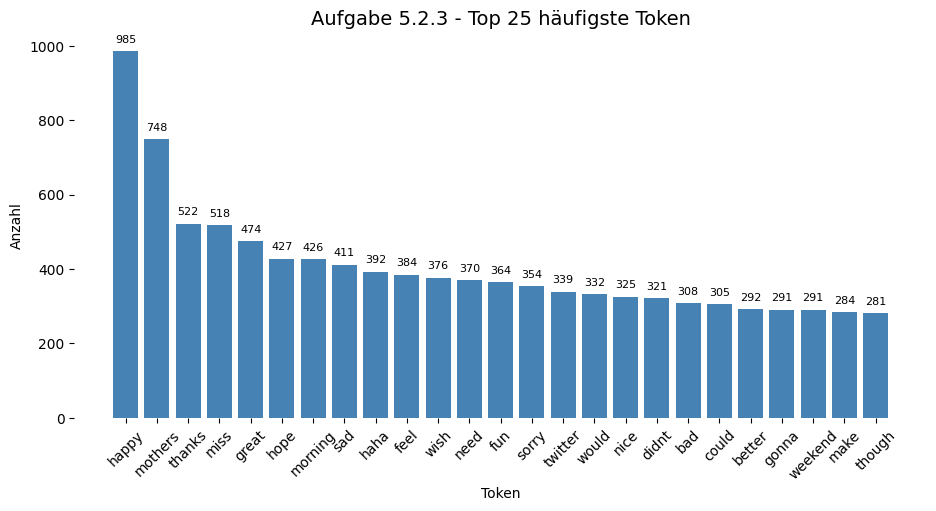

In [33]:
plot_top_words()

### 5.2.6 Byte Pair Encoding

Anzahl BPE-token (insgesamt): 139347
Anzahl einzigartiger BPE-token |V|: 13398

Beispiel:
  Original:   funnywell say bye bc deliriouslol worked hrs thinkcrazyanyhoo bye lady
  BPE-token: ['funny', 'well', 'say', 'bye', 'bc', 'delirious', 'lol', 'worked', 'hrs', 'think', 'crazy', 'anyhoo', 'bye', 'lady']


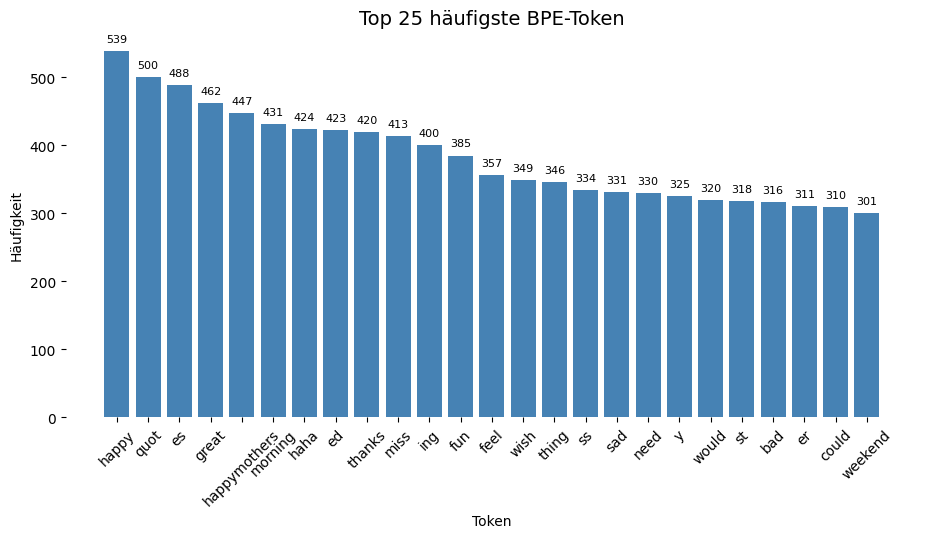

In [34]:
tokenizer = Tokenizer(BPE())
tokenizer.train_from_iterator(df.token.tolist(), BpeTrainer(vocab_size=15000))

bpe_corpus = df.token.apply(" ".join)

# Alle Tweets codieren und Häufigkeiten zählen
all_token = []
for sentence in bpe_corpus:
    all_token.extend(tokenizer.encode(sentence).tokens)

print(f"Anzahl BPE-token (insgesamt): {len(all_token)}")
print(f"Anzahl einzigartiger BPE-token |V|: {len(set(all_token))}")

# Beispiel
print(f"\nBeispiel:")
print(f"  Original:   {bpe_corpus.iloc[0]}")
print(f"  BPE-token: {tokenizer.encode(bpe_corpus.iloc[0]).tokens}")

# Barchart Top 25
top_n = 25
token_freq = pd.Series(all_token).value_counts()
top_token = token_freq.head(top_n)

_, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_token.index, top_token.values, color="steelblue")
ax.set_title(f"Top {top_n} häufigste BPE-Token", fontsize=14)
ax.set_xlabel("Token")
ax.set_ylabel("Häufigkeit")
ax.tick_params(axis="x", rotation=45)
ax.spines[:].set_visible(False)
_ = ax.bar_label(bars, padding=5, fontsize=8)
plt.show()

Byte Pair Encoding (BPE) arbeitet nicht auf Wortebene, sondern auf Zeichenebene. Es startet mit einzelnen Zeichen und fasst schrittweise die häufigsten Zeichenpaare zu Teilwörtern zusammen. 

Je nach konfigurierter Vocabulary Size sinkt die Anzahl der Word Types da seltene Wörter in wiederverwendbare Teilwörter zerlegt werden. Gleichzeitig steigt die Zahl der Word Instances, weil Wörter nun aus mehreren Teilwörtern bestehen können.

- **Niedrig** (z. B. 500): Die meisten Wörter werden in Einzelzeichen aufgeteilt.
- **Mittel** (z. B. 5000, siehe Barchart): Häufige Wörter bleiben erhalten, seltene werden in geteilt.
- **Hoch** (z. B. 28000, ca. ursprüngliches Vokabular): Fast alle Wörter bleiben ganz. Kaum Unterschied zur Whitespace Tokenisierung.

`s` wird zum am häufig auftretenden Token. Wörter mit Endung auf `s` (z. B. „feels", „says") werden als Stamm + `s` gespeichert.

Für unseren Anwendungsfall mit klassischen Machine Learning Klassifikatoren sowie Deep Learning, bietet BPE keinen Mehrwert. Die Zerlegung in Teilwörter reduziert die Aussagekraft der Features. BPE wird daher im weiteren Verlauf nicht verwendet.

### Lemmatisierung

In [35]:
lemmatizer = WordNetLemmatizer()
df["token"] = df.token.apply(lambda token: [lemmatizer.lemmatize(w) for w in token])

Anzahl Token (insgesamt):  111784
Anzahl einzigartiger Token |V|: 19319


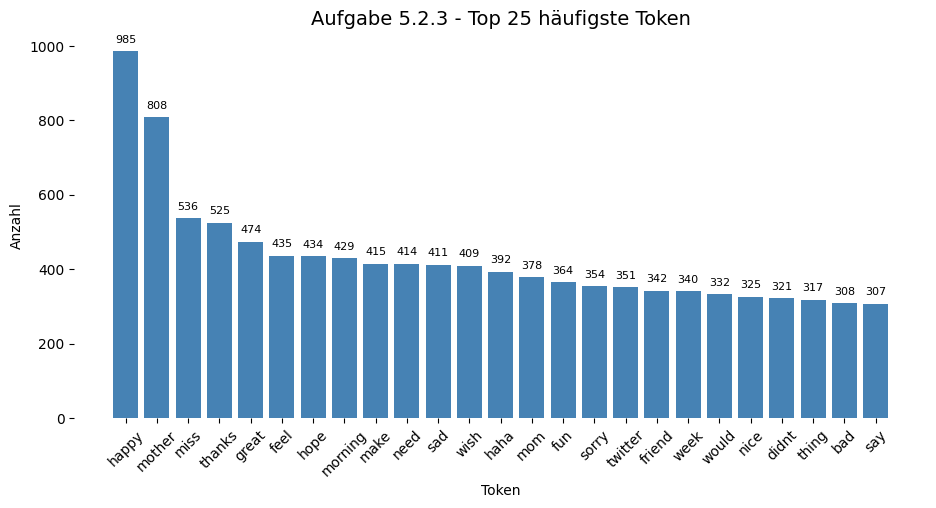

In [36]:
plot_top_words()

Lemmatisierung reduziert jedes Wort auf seine Grundform (Lemma) anhand eines Wörterbuchs: z. B. „running" → „run", „says" → „say", „happier" → „happy".

**Warum Lemmatisierung statt BPE?**

BPE zerlegt Wörter in Teilwörter und erzeugt damit Features wie `happ`, `iness` oder `s`. Lemmatisierung dagegen fasst bedeutungsgleiche Wortformen zusammen (`happy`, `happier`, `happiest` → `happy`) und reduziert so den Wortschatz ohne Informationsverlust.

## 5.3 Vektorisierung

Nach Datenaufbereitung kann der finale Datenkorpus definiert werden. Die zuvor durch Whitespace Tokenization erzeugte Tokenliste wird zur weiteren Verwendung in der Vektorisierung und Modellierung wieder in einen String umgewandelt.

In [37]:
corpus = df.token.apply(" ".join)
labels = df.emotion

### 5.3.1 Bag-of-Words (`CountVectorizer`)

In [38]:
bow_vectorizer = CountVectorizer()
corpus_bow = bow_vectorizer.fit_transform(corpus)

print("Anzahl der Features: " + str(bow_vectorizer.get_feature_names_out().shape[0]))
print(corpus_bow)

Anzahl der Features: 19295
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 108408 stored elements and shape (18845, 19295)>
  Coords	Values
  (0, 6209)	1
  (0, 14437)	1
  (0, 2373)	2
  (0, 1405)	1
  (0, 4150)	1
  (0, 18805)	1
  (0, 7723)	1
  (0, 16701)	1
  (0, 9027)	1
  (1, 9894)	1
  (1, 5607)	1
  (1, 1609)	1
  (1, 15975)	1
  (1, 14417)	1
  (1, 18705)	1
  (1, 1731)	1
  (2, 15821)	1
  (2, 9568)	1
  (2, 6781)	1
  (3, 10772)	1
  (3, 750)	1
  (3, 17532)	1
  (3, 6208)	1
  (4, 13724)	1
  (4, 9199)	1
  :	:
  (18841, 1707)	1
  (18841, 15611)	1
  (18841, 6865)	1
  (18841, 14534)	1
  (18841, 1007)	1
  (18841, 14220)	1
  (18841, 1428)	1
  (18841, 5589)	1
  (18842, 9616)	1
  (18842, 10100)	1
  (18842, 5722)	1
  (18842, 11900)	1
  (18842, 17335)	1
  (18843, 11132)	1
  (18843, 5151)	1
  (18843, 10116)	1
  (18843, 711)	1
  (18844, 10960)	1
  (18844, 18484)	1
  (18844, 11619)	1
  (18844, 18827)	1
  (18844, 9443)	1
  (18844, 8517)	1
  (18844, 196)	1
  (18844, 2477)	1


### 5.3.2 TF-IDF Ansatz (`TfidfVectorizer`)

In [39]:
tfidf_vectorizer = TfidfVectorizer()
corpus_tfidf = tfidf_vectorizer.fit_transform(corpus)

print("Anzahl der Features: " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))
print(corpus_tfidf)

Anzahl der Features: 19295
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 108408 stored elements and shape (18845, 19295)>
  Coords	Values
  (0, 6209)	0.37108579178928036
  (0, 14437)	0.18815701016431502
  (0, 2373)	0.5213368221201371
  (0, 1405)	0.27208786223950054
  (0, 4150)	0.37108579178928036
  (0, 18805)	0.27875297377530134
  (0, 7723)	0.26066841106006855
  (0, 16701)	0.37108579178928036
  (0, 9027)	0.2449649304142432
  (1, 9894)	0.26670344479833874
  (1, 5607)	0.2645966043437408
  (1, 1609)	0.28650355983160153
  (1, 15975)	0.4429825573118004
  (1, 14417)	0.4063037979797699
  (1, 18705)	0.45781698514712
  (1, 1731)	0.4537189719218217
  (2, 15821)	0.8105821089929902
  (2, 9568)	0.43508501796956345
  (2, 6781)	0.39199192812977784
  (3, 10772)	0.6051865315617184
  (3, 750)	0.6051865315617184
  (3, 17532)	0.35275354420622856
  (3, 6208)	0.37823730789352206
  (4, 13724)	0.4695482261642565
  (4, 9199)	0.4271635789588644
  :	:
  (18841, 1707)	0.22660402500335053
  (18841,

Beide Vektorisierungen (Bag-of-Words und TF-IDF) wurden in gleich große Matrizen umgewandelt. Diese umfassen jeweils 18.845 Zeilen und 19.295 Spalten. Eine vollständige Matrix würde demnach über 360 Mio. Zellen enthalten. Das Sparse-Matrix-Format speichert jedoch nur die Werte ungleich 0, in diesem Fall 108408 Werte.

Auffällig ist der Unterschied im Zahlenformat. Während BoW ganzzahlige Integer speichert (z.B. 3, wenn ein Wort dreimal vorkommt), enthält TF-IDF Fließkommazahlen zwischen 0 und 1, abhängig von der gewichteten Häufigkeit pro Wort. Häufige Wörter, die in vielen Dokumenten vorkommen, erhalten dabei ein niedrigeres Gewicht, während seltenere aber charakteristische Wörter ein höheres Gewicht erhalten.

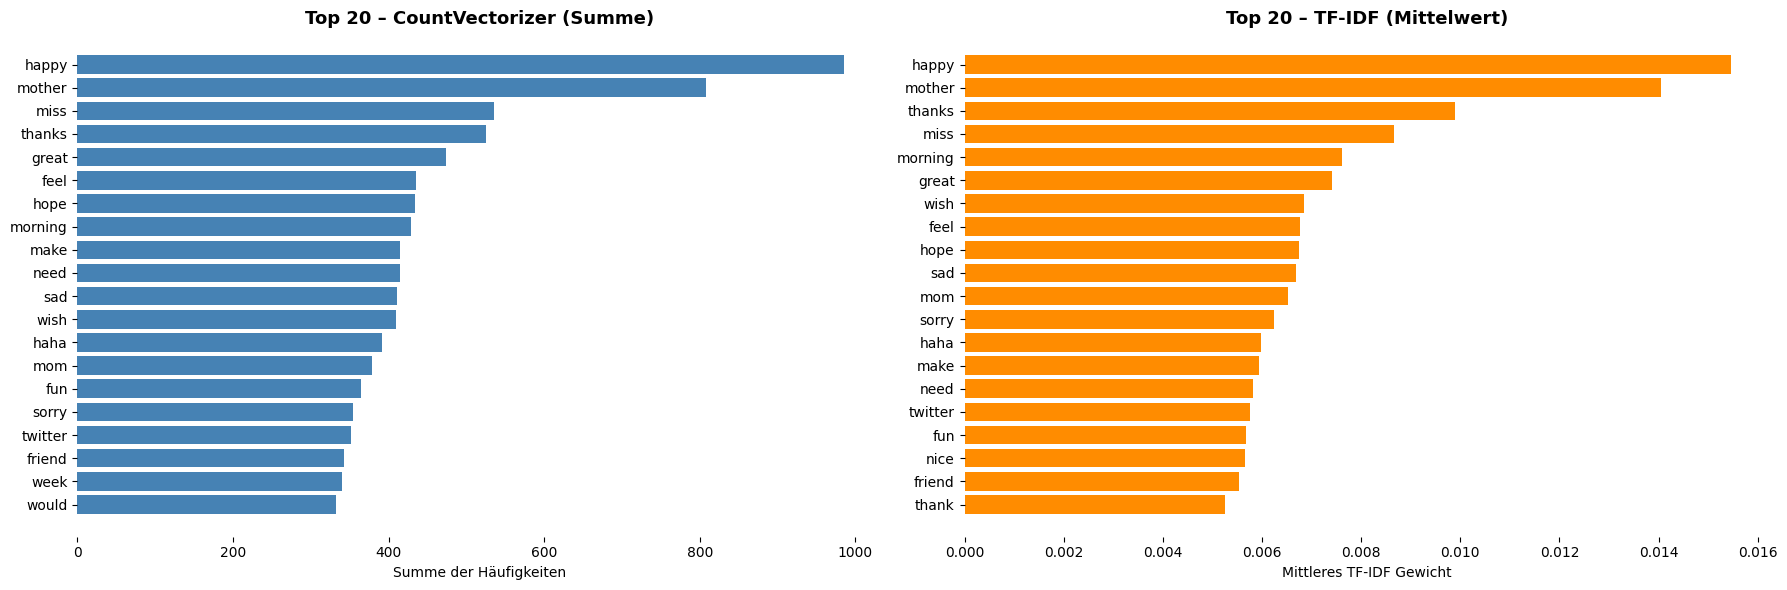

In [40]:
top_n = 20
feature_names = bow_vectorizer.get_feature_names_out()

# Top N by sum of counts
count_sums = np.asarray(corpus_bow.sum(axis=0)).flatten()
top_count_idx = count_sums.argsort()[::-1][:top_n]

# Top N by mean TF-IDF weight
tfidf_means = np.asarray(corpus_tfidf.mean(axis=0)).flatten()
top_tfidf_idx = tfidf_means.argsort()[::-1][:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.barh(feature_names[top_count_idx][::-1], count_sums[top_count_idx][::-1], color="steelblue")
ax1.set_title(f"Top {top_n} – CountVectorizer (Summe)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.spines[:].set_visible(False)

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
ax2.barh(tfidf_feature_names[top_tfidf_idx][::-1], tfidf_means[top_tfidf_idx][::-1], color="darkorange")
ax2.set_title(f"Top {top_n} – TF-IDF (Mittelwert)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Mittleres TF-IDF Gewicht")
ax2.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

### 5.3.3 N-gram Ansatz

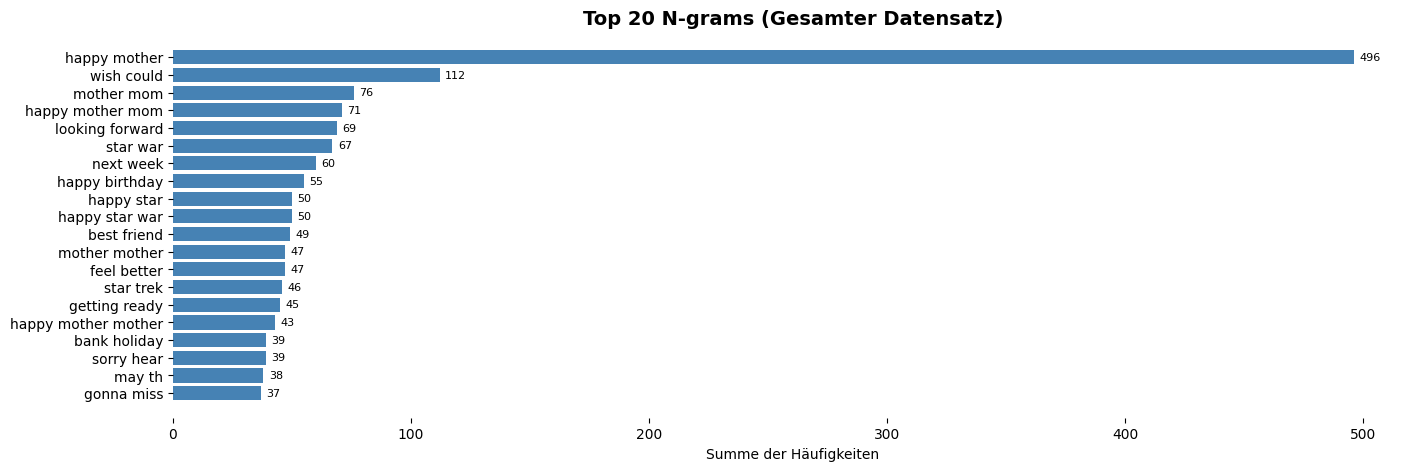

In [41]:
# N-gram Vektorisierung mit CountVectorizer
ngram_vectorizer = CountVectorizer(ngram_range=(2, 4))

# ngram_range gibt das untere und obere ende für n-grams an
#   ngram_range(1,1): nur Unigrams (default)
#   ngram_range(2,2): nur Bigrams
#   ngram_range(1,2): Unigrams und Bigrams

# Lernen des Vokabulars aus dem ganzen Korpus
X_ngram = ngram_vectorizer.fit_transform(corpus)                                 

# Bigram-Counts summieren
ngram_counts = X_ngram.sum(axis=0).A1

top_idx = ngram_counts.argsort()[::-1][:20]
top_features = ngram_vectorizer.get_feature_names_out()[top_idx]
top_values = ngram_counts[top_idx]

_, ax1 = plt.subplots(1, 1, figsize=(16, 5))

bars1 = ax1.barh(top_features[::-1], top_values[::-1], color="steelblue")
ax1.set_title("Top 20 N-grams (Gesamter Datensatz)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Summe der Häufigkeiten")
ax1.bar_label(bars1, fmt="{:.0f}", padding=4, fontsize=8)
ax1.spines[:].set_visible(False)

plt.show()

Durch die N-grams werden häufige Wortzusammensetzungen sichtbar gemacht. Der Datensatz enthält besonders häufig "Happy mother" (481), "Mother mum" (67) und "Happy Mother Mom" (63)... Häufige n-gram Kombinatationen sind in mehrere Emotionklassen vertreten (siehe Grafik unten) und daher nicht trennscharf einer Emotion zuordbar. Woher kommt das? Nach manueller Sichtung der Tweet csv-Datei, zeigte sich dass im Zeitraum der Datenerhebung der Muttertag stattgefunden hat und viele Tweets (>700) daher diesen thematisieren. Die lässt sich an an den beiden Vektorisierungen ohne N-grams erkennen, da "happy" und "mother" die meist genannten Token sind.

Zu lange n-grams könnten Overfitting an den Trainingssatz begünstigen und die Generalisierbarkeit auf andere fremde Datensätze einschränken.

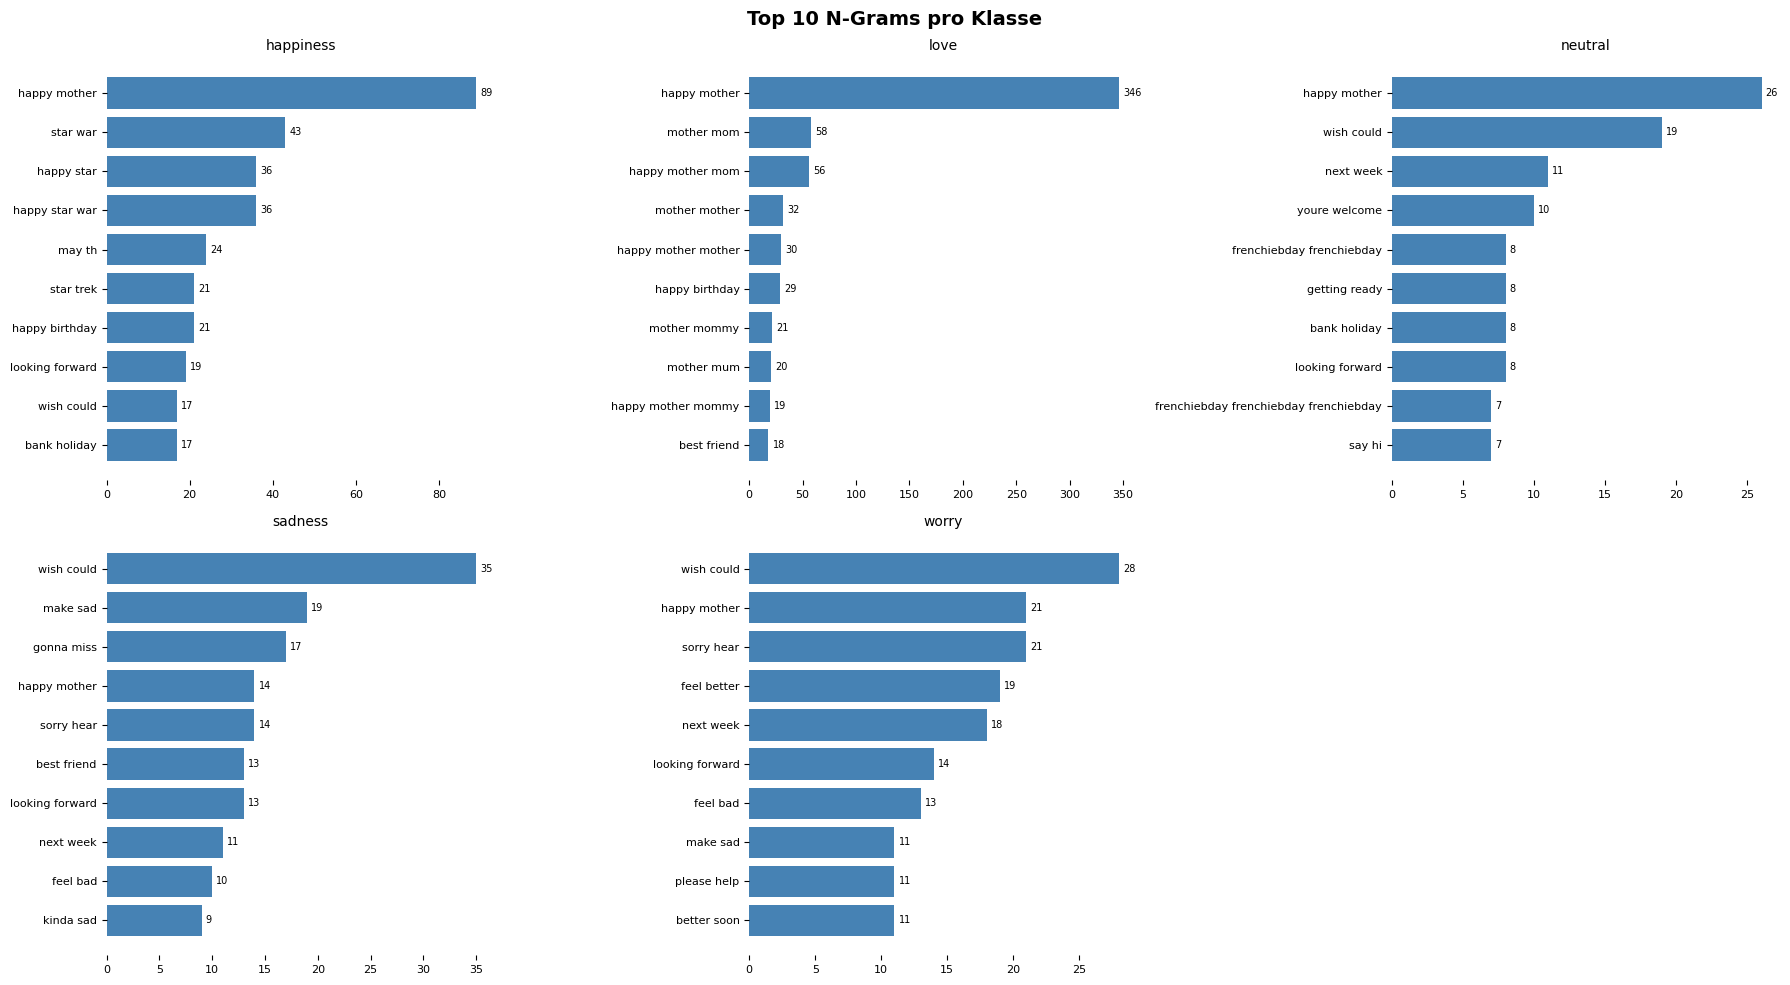

In [42]:
classes = sorted(labels.unique())
ngram_names = ngram_vectorizer.get_feature_names_out()
y_train_arr = labels.values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Top 10 N-Grams pro Klasse", fontsize=14, fontweight="bold")

for row, cls in enumerate(classes):
    mask = y_train_arr == cls

    cls_count = np.asarray(X_ngram[mask].sum(axis=0)).flatten()
    top_idx = cls_count.argsort()[::-1][:10]
    ax = axes[row]
    bars = ax.barh(ngram_names[top_idx][::-1], cls_count[top_idx][::-1], color="steelblue")
    ax.set_title(f"{cls}", fontsize=10)
    ax.bar_label(bars, fmt="{:.0f}", padding=3, fontsize=7)
    ax.spines[:].set_visible(False)
    ax.tick_params(labelsize=8)

for ax in axes[len(classes):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
# Mean count per class for every n-gram
class_scores = np.vstack([
    np.asarray(X_ngram[y_train_arr == cls].mean(axis=0)).flatten()
    for cls in classes
])  # shape: (n_classes, n_features)

# Only keep n-grams that appear in exactly one class
exclusive_mask = (class_scores > 0).sum(axis=0) == 1

unique_ngrams = {}
for i, cls in enumerate(classes):
    class_exclusive = exclusive_mask & (class_scores[i] > 0)
    candidate_idx = np.where(class_exclusive)[0]
    top_idx = candidate_idx[class_scores[i][candidate_idx].argsort()[::-1][:10]]
    unique_ngrams[cls] = ngram_names[top_idx].tolist()

pd.DataFrame(unique_ngrams)

,happiness,love,neutral,sadness,worry
0,thanks everyone,world happy,frenchiebday frenchiebday,kinda sad,whole body
1,happy juddday,wishing mother,frenchiebday frenchiebday frenchiebday,low low,school next
2,finally dinner,lovely weekend,frenchiebday frenchiebday frenchiebday frenchi...,made sad,hope didnt
3,sooo fun,mother enjoy,ok might,low low low,getting worse
4,two year,mother lt,united state,low low low low,twitter thing
5,show amazing,shes cute,jt snl,life suck,make stop
6,hahaha yes,wishing mother happy mother,follow dm,gonna cry,yeah late
7,woot woot,wishing mother happy,fellow tweeter,mile away,sun come
8,look amazing,happy birthday happy birthday,eddie izzard,sad leave,school suck
9,thank thank,happy birthday happy,card card,sad thought,might need


# Step 4: Modellierung

## 6.1 Machine Learning

**Inputvariablen:** Als Eingabe für die Modelle verwenden wir verschiedene Vektorrepräsentationen unseres der Trainingskorpera. Konkret vergleichen wir Bag-of-Words (mit dem CountVectorizer) und TF-IDF. Jeder Tweet wird dabei als Vektor repräsentiert, dessen Dimensionen den Häufigkeiten bzw. Gewichtungen der enthaltenen token entsprechen.

**Outputvariablen:** Die Zielvariable ist die Emotionskategorie eines Tweets. Das Modell ordnet jedem Eingabevektor eine dieser Klassen zu. Die Güte der Vorhersage wird anschließend anhand der Testdaten mit dem F1-Score gemessen, der Präzision und Recall über alle Klassen gleichgewichtig berücksichtigt.

## 6.2 Prediction vs. Inference

+ **Prediction:**  Unser Ziel ist die möglichst genaue Vorhersage (Prediction) der Emotion, nicht die Erklärung kausaler Zusammenhänge zwischen Features und Label wie bei Inference gefordert.

+ **Inference:**
Eine Frage wäre daher welche Inputvariable (Wörter) ein Indikator für eine spezifische Emotion ist und zu welcher Warscheinlichkeit. Die Wortfrequezanalyse 

## 6.3 Classification vs. Regression

Im vorliegenden Anwendungsfall handelt es sich um eine Klassifikation, da die Zielvariablen aus Klassen besteht und keine kontinuierliche Werte vorhergesagt werden.


## 7.1 Training und Test von Modellen

### 7.1.1 Trainings-, Validierungs- und Testdaten

In [44]:
# Split: 70% Train / 15% Validation / 15% Test
X_train, X_test, y_train, y_test = train_test_split(corpus, labels, test_size=0.15, random_state=42)

# 0.176 ≈ 15/85, sodass Validation und Test gleich groß
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.176, random_state=42)

In [45]:
total = len(X_train) + len(X_val) + len(X_test)

print(f"Train      ({len(X_train)/total*100:.0f}%) : {len(X_train)}")
print(f"Validation ({len(X_val)/total*100:.0f}%) : {len(X_val)}")
print(f"Test       ({len(X_test)/total*100:.0f}%) : {len(X_test)}")

Train      (70%) : 13198
Validation (15%) : 2820
Test       (15%) : 2827


In [46]:
print(X_train)

15294         ohhh miss piston hope joe cook something big
8922                                           playing uno
11292                                  look schuhz arabyrd
17993                               ugh economy depressing
3258                      quotleave piecesquot wrecker hmm
                               ...                        
11738           fuck feel cry bit realy bothering sooooooo
3751     twitter useful reminds people forgot ask given...
11560                        waiting aaron town leave booo
16482    laptop broke want help girl take best buy week...
15345                                     happened winston
Name: token, Length: 13198, dtype: str


In [47]:
print(y_test)

17138        worry
423      happiness
11434      sadness
14783      sadness
5216          love
           ...    
11438      sadness
9676       neutral
10423      neutral
13523      sadness
6759          love
Name: emotion, Length: 2827, dtype: str


`min_df=5`: Ein Token muss in mindestens 5 Dokumenten vorkommen, um ins Vokabular aufgenommen zu werden. Filtert seltene Wörter und, die nicht generalisieren.

`max_df=0.8`: Ein Token, das in mehr als 80% aller Dokumente vorkommt, wird ignoriert. Das entfernt sehr häufige Wörter (ähnlich wie Stoppwörter), die keine Unterscheidungskraft zwischen den Emotionsklassen haben. Diese Vorgehensweise ist ähnlich zu der erweiterten Stopword-Entfernung wie in 5.2.1 dokumentiert. Der Unterschied liegt jedoch im Fokus auf 80% der Dokumente (Tweets) statt auf die Klassen.

In [48]:
bow_vectorizer = CountVectorizer(min_df=50, max_df=0.6)
# bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

features_bow = (X_train_bow, X_val_bow, X_test_bow)

print("Anzahl der Spalten (Feature): " + str(bow_vectorizer.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 278


In [49]:
count_vectorizer_ngram = CountVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.8)
# count_vectorizer_ngram = CountVectorizer(ngram_range=(1, 3))

X_train_bow_ngram = count_vectorizer_ngram.fit_transform(X_train)
X_val_bow_ngram = count_vectorizer_ngram.transform(X_val)
X_test_bow_ngram = count_vectorizer_ngram.transform(X_test)

features_bow_ngram = (X_train_bow_ngram, X_val_bow_ngram, X_test_bow_ngram)

print("Anzahl der Spalten (Feature): " + str(count_vectorizer_ngram.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 2588


In [50]:
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.8)
# tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

features_tfidf = (X_train_tfidf, X_val_tfidf, X_test_tfidf)

print("Anzahl der Spalten (Feature): " + str(tfidf_vectorizer.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 2279


In [51]:
tfidf_vectorizer_ngram = TfidfVectorizer(ngram_range=(1, 3), min_df=5, max_df=0.8)
# tfidf_vectorizer_ngram = TfidfVectorizer(ngram_range=(1, 3))

X_train_tfidf_ngram = tfidf_vectorizer_ngram.fit_transform(X_train)
X_val_tfidf_ngram = tfidf_vectorizer_ngram.transform(X_val)
X_test_tfidf_ngram = tfidf_vectorizer_ngram.transform(X_test)

features_tfidf_ngram = (X_train_tfidf_ngram, X_val_tfidf_ngram, X_test_tfidf_ngram)

print("Anzahl der Spalten (Feature): " + str(tfidf_vectorizer_ngram.get_feature_names_out().shape[0]))

Anzahl der Spalten (Feature): 2588


### 7.1.2 Training

In [52]:
# results = {}    # Initialisierung eines leeren Feldes für Speicherung der besten Trainingsergebnisse

In [53]:
from scipy.sparse import vstack
from sklearn.model_selection import PredefinedSplit

def tune_hyperparameter(classifier, param_grid, features, name=None, save_best_model=False):
    X_train, X_val, X_test = features

    gs = GridSearchCV(classifier, param_grid=param_grid, cv=3, scoring="f1_macro")
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_pred_val = best_model.predict(X_val)
    y_pred_train = best_model.predict(X_train)

    f1_validation = f1_score(y_val, y_pred_val, average="macro")
    f1_training = f1_score(y_train, y_pred_train, average="macro")

    print(f"Best params: {gs.best_params_}  |  F1-Score (val): {f1_validation:.3f} |  F1-Score (train): {f1_training:.3f}")

    if save_best_model:
        # Klassifikationsreport erzeugen
        print(f"=== {name} ===\n{classification_report(y_val, y_pred_val, zero_division=0)}")

        print(f"F1-Score (Validation): {f1_validation:.3f}")
        print(f"F1-Train (Training): {f1_training:.3f}")

        results[name] = (f1_validation, best_model, X_train, X_val, X_test)

    # return (gs.best_params_, gs.best_estimator_)
    return

#### K Nearest Neighbor

In [54]:
knn_classifier = KNeighborsClassifier()

Hier wird untersucht welche Vektorisierung in Verbindung mit KNN das beste F1 Scoring für KNN ergibt. Für die bessere Nachvollziehbarkeit werden kurz die verschiedenen Trainingsdatensätze aufgelistet

+ BoW:  X_count_train (F1:0.294)
+ TFIDF: X_tfidf_train (F1:0.251)
+ Ngrams + BoW: X_count_ngram_train (F1: 0.296)
+ Ngram + TFIDF: X_tfidf_ngram_train (F1: 0.254)

##### Hyperparametertuning: KNN mit BoW Vektorisierung

In [55]:
parameter = {
    "n_neighbors": [1, 3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=knn_classifier, param_grid=parameter, features=features_bow)

Best params: {'n_neighbors': 16}  |  F1-Score (val): 0.323 |  F1-Score (train): 0.399


Optimum KNN mit BoW liegt vermutlich bei k=5.

In [56]:
# Zweiter GridSearch
parameter = {
    "n_neighbors": [2, 4, 5, 6, 7]
}

tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="KNN: BoW",
    save_best_model=True
)

Best params: {'n_neighbors': 7}  |  F1-Score (val): 0.324 |  F1-Score (train): 0.451
=== KNN: BoW ===
              precision    recall  f1-score   support

   happiness       0.34      0.40      0.37       564
        love       0.38      0.31      0.34       580
     neutral       0.30      0.50      0.37       575
     sadness       0.39      0.27      0.32       550
       worry       0.28      0.18      0.22       551

    accuracy                           0.33      2820
   macro avg       0.34      0.33      0.32      2820
weighted avg       0.34      0.33      0.32      2820

F1-Score (Validation): 0.324
F1-Train (Training): 0.451


##### Hyperparametertuning: KNN mit BoW Vektorisierung und N-gram

In [57]:
parameter = {
    "n_neighbors": [1, 3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_bow_ngram)

Best params: {'n_neighbors': 8}  |  F1-Score (val): 0.291 |  F1-Score (train): 0.450


Optimum KNN mit BoW und Ngrams liegt vermutlich bei k=8.

In [58]:
# Zweiter GridSearch
parameter = {
    "n_neighbors": [6, 7, 8, 9, 10]
}

tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_bow_ngram,
    name="KNN: BoW + Ngram",
    save_best_model=True
)

Best params: {'n_neighbors': 8}  |  F1-Score (val): 0.291 |  F1-Score (train): 0.450
=== KNN: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.28      0.36      0.32       564
        love       0.35      0.27      0.30       580
     neutral       0.28      0.55      0.37       575
     sadness       0.41      0.25      0.31       550
       worry       0.28      0.10      0.15       551

    accuracy                           0.31      2820
   macro avg       0.32      0.31      0.29      2820
weighted avg       0.32      0.31      0.29      2820

F1-Score (Validation): 0.291
F1-Train (Training): 0.450


##### Hyperparametertuning: KNN mit TF-IDF Vektorisierung

In [59]:
parameter = {
    "n_neighbors": [1, 3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_tfidf)

Best params: {'n_neighbors': 1}  |  F1-Score (val): 0.270 |  F1-Score (train): 0.939


Optimum KNN mit TF-IDF liegt vermutlich bei k=1.

In [60]:
# Zweiter GridSearch
parameter = {
    "n_neighbors": [1, 2, 4]
}

tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_tfidf,
    name="KNN: TF-IDF",
    save_best_model=True
)

Best params: {'n_neighbors': 1}  |  F1-Score (val): 0.270 |  F1-Score (train): 0.939
=== KNN: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.26      0.22      0.24       564
        love       0.32      0.31      0.31       580
     neutral       0.25      0.42      0.31       575
     sadness       0.31      0.23      0.26       550
       worry       0.26      0.19      0.22       551

    accuracy                           0.28      2820
   macro avg       0.28      0.27      0.27      2820
weighted avg       0.28      0.28      0.27      2820

F1-Score (Validation): 0.270
F1-Train (Training): 0.939


##### Hyperparametertuning: KNN mit TF-IDF Vektorisierung und N-gram

In [61]:
parameter = {
    "n_neighbors": [1, 3, 5, 8, 11, 15, 16, 18, 20, 21, 25]
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(knn_classifier, parameter, features_tfidf_ngram)

Best params: {'n_neighbors': 1}  |  F1-Score (val): 0.254 |  F1-Score (train): 0.939


Optimum KNN mit TF-IDF und Ngrams liegt vermutlich bei k=1.

In [62]:
# Zweiter GridSearch
parameter = {
    "n_neighbors": [1, 2, 4]
}

tune_hyperparameter(
    classifier=knn_classifier, 
    param_grid=parameter, 
    features=features_tfidf_ngram,
    name="KNN: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'n_neighbors': 1}  |  F1-Score (val): 0.254 |  F1-Score (train): 0.939
=== KNN: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.25      0.20      0.23       564
        love       0.31      0.31      0.31       580
     neutral       0.24      0.39      0.29       575
     sadness       0.27      0.20      0.23       550
       worry       0.24      0.20      0.22       551

    accuracy                           0.26      2820
   macro avg       0.26      0.26      0.25      2820
weighted avg       0.26      0.26      0.26      2820

F1-Score (Validation): 0.254
F1-Train (Training): 0.939


#### Decision Tree

In [63]:
dtc_classifier = DecisionTreeClassifier(random_state=42)

##### Hyperparametertuning: DTC mit BoW Vektorisierung

In [64]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
dtc_1 = DecisionTreeClassifier(random_state=42)
dtc_1.fit(X_train_bow, y_train)

print(f"Tiefe: {str(dtc_1.get_depth())}")
print(f"Blätter: {str(dtc_1.get_n_leaves())}\n")

# Vorhersagen & Bewertung
dt_train_predict = dtc_1.predict(X_train_bow)
dt_test_predict = dtc_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

# path = dt_classifier.cost_complexity_pruning_path(X_count_train, y_train)
# print(len(path["ccp_alphas"]))

Tiefe: 296
Blätter: 6830

F1-Score (Validation): 0.335
F1-Train (Train): 0.764


Der Baum ist bereits relativ groß (Viele Blätter und hohe Tief). Dies lässt auf starkes Overfitting schließen, was durch den großen Unterschied zwischen den F1-Scores für Train und Test nur verdeutlicht wird. Um das Overfitting zu verhindern, sollte die größe des Baums eingeschränkt werden.

Der Parameter min_sample_leafs legt fest, wie viele Samples ein Blatt mindestens umfassen muss. Dieser Parameter beschränkt implizit auch die maximale Tiefe des Baums. Ziel ist das Overfitting durch Abbildung einzelner Samples auf einzelne Blätter zu reduzieren. Im folgenden wird ein weiterer Test durchgeführt mit Beschränkung der Mindestanzahl auf 10 Samples pro Blatt. 

In [65]:
# Zweiter einfacher Decision Tree als Anhaltspunkt für Parameter
dtc_2 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
dtc_2.fit(X_train_bow, y_train)

print(f"Tiefe: {str(dtc_2.get_depth())}")
print(f"Blätter: {str(dtc_2.get_n_leaves())} \n")

# Vorhersagen & Bewertung
dt_train_predict = dtc_2.predict(X_train_bow)
dt_test_predict = dtc_2.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}") 

# path = dt_classifier.cost_complexity_pruning_path(X_count_train, y_train)
# print(len(path["ccp_alphas"]))

Tiefe: 230


Blätter: 293 

F1-Score (Validation): 0.385
F1-Train (Train): 0.413


Der zweite Test-Baum mit min_samples_leaf zeigt sowohl einen deutlich höheren F1-Score im Test auf, als auch stark verringertes Overfitting. Dies unterstreicht die Notwendigkeit von Hyperparametertuning.

In [66]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 8}  |  F1-Score (val): 0.384 |  F1-Score (train): 0.411


Optimum DT mit BoW liegt vermutlich bei
+ min_sample_leaf=8
+ ccp_alpha=0.0001


In [67]:
# Zweiter GridSearch
parameter = {
    "min_samples_leaf": [1, 8, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="DTC: BoW",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 8}  |  F1-Score (val): 0.384 |  F1-Score (train): 0.411
=== DTC: BoW ===
              precision    recall  f1-score   support

   happiness       0.37      0.44      0.40       564
        love       0.44      0.35      0.39       580
     neutral       0.36      0.52      0.42       575
     sadness       0.47      0.38      0.42       550
       worry       0.34      0.25      0.29       551

    accuracy                           0.39      2820
   macro avg       0.39      0.39      0.38      2820
weighted avg       0.39      0.39      0.38      2820

F1-Score (Validation): 0.384
F1-Train (Training): 0.411


##### Hyperparametertuning: DTC mit BoW Vektorisierung und Ngrams

In [68]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 8}  |  F1-Score (val): 0.403 |  F1-Score (train): 0.440


In [69]:
# Zweiter GridSearch
parameter = {
    "min_samples_leaf": [1, 8, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_bow_ngram,
    name="DTC: BoW + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 8}  |  F1-Score (val): 0.403 |  F1-Score (train): 0.440
=== DTC: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.39      0.48      0.43       564
        love       0.47      0.35      0.40       580
     neutral       0.39      0.49      0.43       575
     sadness       0.45      0.46      0.46       550
       worry       0.34      0.25      0.29       551

    accuracy                           0.41      2820
   macro avg       0.41      0.41      0.40      2820
weighted avg       0.41      0.41      0.40      2820

F1-Score (Validation): 0.403
F1-Train (Training): 0.440


##### Hyperparametertuning: DTC mit TF-IDF Vektorisierung

In [70]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 9}  |  F1-Score (val): 0.372 |  F1-Score (train): 0.491


In [71]:
# Zweiter GridSearch
parameter = {
    "min_samples_leaf": [1, 7, 9, 13, 20, 100],
    "ccp_alpha": [0, 0.0001, 0.001]
}

tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_tfidf,
    name="DTC: TF-IDF",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 9}  |  F1-Score (val): 0.372 |  F1-Score (train): 0.491
=== DTC: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.35      0.42      0.38       564
        love       0.42      0.36      0.39       580
     neutral       0.38      0.46      0.42       575
     sadness       0.42      0.37      0.40       550
       worry       0.31      0.25      0.28       551

    accuracy                           0.38      2820
   macro avg       0.38      0.37      0.37      2820
weighted avg       0.38      0.38      0.37      2820

F1-Score (Validation): 0.372
F1-Train (Training): 0.491


##### Hyperparametertuning: DTC mit TF-IDF Vektorisierung und Ngrams

In [72]:
parameter = {
    "min_samples_leaf": [8, 9, 10, 11, 12],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001, 0.005, 0.01, 0.05]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 12}  |  F1-Score (val): 0.380 |  F1-Score (train): 0.471


In [73]:
parameter = {
    "min_samples_leaf": [1, 7, 9, 13, 20, 100],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 20}  |  F1-Score (val): 0.378 |  F1-Score (train): 0.437


In [74]:
parameter = {
    "min_samples_leaf": [18, 19, 20, 21, 22],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]      # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=dtc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 19}  |  F1-Score (val): 0.379 |  F1-Score (train): 0.441


In [75]:
# Zweiter GridSearch
parameter = {
    "min_samples_leaf": [1, 10, 19, 20, 21],
    "ccp_alpha": [0, 0.0001, 0.001]
}

tune_hyperparameter(
    classifier=dtc_classifier, 
    param_grid=parameter, 
    features=features_tfidf_ngram,
    name="DTC: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 19}  |  F1-Score (val): 0.379 |  F1-Score (train): 0.441
=== DTC: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.39      0.35      0.37       564
        love       0.41      0.38      0.39       580
     neutral       0.36      0.55      0.43       575
     sadness       0.42      0.38      0.40       550
       worry       0.36      0.26      0.30       551

    accuracy                           0.38      2820
   macro avg       0.39      0.38      0.38      2820
weighted avg       0.39      0.38      0.38      2820

F1-Score (Validation): 0.379
F1-Train (Training): 0.441


#### Random forest

Hier wird untersucht welche Vektorisierung in Verbindung mit Random Forest das beste F1 Scoring für Random Forest ergibt. Für die bessere Nachvollziehbarkeit werden kurz die verschiedenen Trainingsdatensätze aufgelistet

+ BoW: X_count_train (F1: 0.401)
+ BoW + Ngram: X_count_ngram_train (F1: 0.419)
+ TF-IDF: X_tfidf_train (F1: 0.415)
+ TF-IDF + Ngram: X_tfidf_ngram_train (F1: 0.414)

In [76]:
rfc_classifier = RandomForestClassifier(random_state=42)

##### Hyperparametertuning: RFC mit BoW Vektorisierung

In [77]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
rfc_1 = RandomForestClassifier(random_state=42)
rfc_1.fit(X_train_bow, y_train)

estimators = rfc_1.estimators_
print(f"n_estimators: {len(estimators)}")
print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

# Vorhersagen & Bewertung
dt_train_predict = rfc_1.predict(X_train_bow)
dt_test_predict = rfc_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

n_estimators: 100
Tiefe (avg): 291.3
Blätter (avg): 4928.6



F1-Score (Validation): 0.356
F1-Train (Train): 0.764


Wir sehen, dass auch beim RandomForest wieder sehr große DecisionTrees entstehen. Diese sollen ebenfalls (wie oben) eingeschränkt werden, um das Overfitting zu reduzieren. Es wird daher ein ähnlicher Ansatz mit min_samples_leaves und ccp_alpha gewählt.

In [78]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
rfc_2 = RandomForestClassifier(n_estimators=50, min_samples_leaf=10, random_state=42)
rfc_2.fit(X_train_bow, y_train)

estimators = rfc_2.estimators_
print(f"n_estimators: {len(estimators)}")
print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

# Vorhersagen & Bewertung
dt_train_predict = rfc_2.predict(X_train_bow)
dt_test_predict = rfc_2.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

n_estimators: 50
Tiefe (avg): 165.0
Blätter (avg): 167.9

F1-Score (Validation): 0.394
F1-Train (Train): 0.420


Die Limitierung von min_samples_leaf konnte das Overfitting des Random Forest Classifiers bereits stark reduziert. Ein n_estimators von 50 limitiert zusätzlich die Anzahl der maximalen DecisionTrees auf 50. Dieser Parameter sowie der ccp_alpha werden im folgenden optimiert.

In [79]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 9, 'n_estimators': 160}  |  F1-Score (val): 0.396 |  F1-Score (train): 0.421


In [80]:
# Zweiter GridSearch
parameter = {
    "n_estimators": [30, 35, 40, 41],
    "min_samples_leaf": [6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 7, 'n_estimators': 41}  |  F1-Score (val): 0.387 |  F1-Score (train): 0.426


In [81]:
# Zweiter GridSearch
parameter = {
    "n_estimators": [39, 40, 41],
    "min_samples_leaf": [5, 6],
    "ccp_alpha": [0, 0.0001]
}

tune_hyperparameter(
    classifier=rfc_classifier, 
    param_grid=parameter, 
    features=features_bow,
    name="RF: BoW",
    save_best_model=True
)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 5, 'n_estimators': 39}  |  F1-Score (val): 0.401 |  F1-Score (train): 0.431
=== RF: BoW ===
              precision    recall  f1-score   support

   happiness       0.42      0.42      0.42       564
        love       0.47      0.36      0.41       580
     neutral       0.36      0.52      0.42       575
     sadness       0.48      0.39      0.43       550
       worry       0.34      0.32      0.33       551

    accuracy                           0.40      2820
   macro avg       0.41      0.40      0.40      2820
weighted avg       0.41      0.40      0.40      2820

F1-Score (Validation): 0.401
F1-Train (Training): 0.431


##### Hyperparametertuning: RFC mit BoW Vektorisierung und Ngrams

In [82]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 9, 'n_estimators': 80}  |  F1-Score (val): 0.407 |  F1-Score (train): 0.455


In [83]:
# Zweiter GridSearch
parameter = {
    "n_estimators": [60, 70, 80, 90, 100],
    "min_samples_leaf": [5, 6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_bow_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 5, 'n_estimators': 90}  |  F1-Score (val): 0.419 |  F1-Score (train): 0.491


In [84]:
# Dritter GridSearch
parameter = {
    "n_estimators": [80, 90, 100],
    "min_samples_leaf": [4, 5, 6],
    "ccp_alpha": [0]
}

tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_bow_ngram,
    name="RF: BoW + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 4, 'n_estimators': 80}  |  F1-Score (val): 0.419 |  F1-Score (train): 0.510
=== RF: BoW + Ngram ===
              precision    recall  f1-score   support

   happiness       0.44      0.46      0.45       564
        love       0.49      0.38      0.43       580
     neutral       0.39      0.53      0.45       575
     sadness       0.47      0.44      0.46       550
       worry       0.34      0.29      0.32       551

    accuracy                           0.42      2820
   macro avg       0.43      0.42      0.42      2820
weighted avg       0.43      0.42      0.42      2820

F1-Score (Validation): 0.419
F1-Train (Training): 0.510


##### Hyperparametertuning: RFC mit TF-IDF Vektorisierung

In [85]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0.0001, 'min_samples_leaf': 9, 'n_estimators': 160}  |  F1-Score (val): 0.414 |  F1-Score (train): 0.496


In [86]:
# Zweiter GridSearch
parameter = {
    "n_estimators": [140, 160, 180],
    "min_samples_leaf": [6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 180}  |  F1-Score (val): 0.415 |  F1-Score (train): 0.532


In [87]:
# Dritter GridSearch
parameter = {
    "n_estimators": [170, 180, 190],
    "min_samples_leaf": [5, 6, 7],
    "ccp_alpha": [0]
}

tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_tfidf,
    name="RF: TF-IDF",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 5, 'n_estimators': 190}  |  F1-Score (val): 0.415 |  F1-Score (train): 0.552
=== RF: TF-IDF ===
              precision    recall  f1-score   support

   happiness       0.42      0.44      0.43       564
        love       0.47      0.40      0.43       580
     neutral       0.39      0.49      0.43       575
     sadness       0.46      0.43      0.45       550
       worry       0.35      0.32      0.33       551

    accuracy                           0.42      2820
   macro avg       0.42      0.42      0.41      2820
weighted avg       0.42      0.42      0.42      2820

F1-Score (Validation): 0.415
F1-Train (Training): 0.552


##### Hyperparametertuning: RFC mit TF-IDF Vektorisierung und Ngrams

In [88]:
parameter = {
    "n_estimators": [10, 20, 40, 80, 160],
    "min_samples_leaf": [9, 10, 11],                 # Tunen von min_samples um 10
    "ccp_alpha": [0, 0.0001, 0.001]    # Tunen von ccp_alpha zur weiteren Reduktion des Overfittings
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 9, 'n_estimators': 160}  |  F1-Score (val): 0.413 |  F1-Score (train): 0.495


In [89]:
# Zweiter GridSearch
parameter = {
    "n_estimators": [140, 160, 180],
    "min_samples_leaf": [6, 7, 8, 9],
    "ccp_alpha": [0, 0.0001]
}

tune_hyperparameter(classifier=rfc_classifier, param_grid=parameter, features=features_tfidf_ngram)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 140}  |  F1-Score (val): 0.414 |  F1-Score (train): 0.531


In [90]:
# Dritter GridSearch
parameter = {
    "n_estimators": [130, 140, 150],
    "min_samples_leaf": [5, 6, 7],
    "ccp_alpha": [0]
}

tune_hyperparameter(
    classifier=rfc_classifier,
    param_grid=parameter,
    features=features_tfidf_ngram,
    name="RF: TF-IDF + Ngram",
    save_best_model=True
)

Best params: {'ccp_alpha': 0, 'min_samples_leaf': 6, 'n_estimators': 130}  |  F1-Score (val): 0.414 |  F1-Score (train): 0.532
=== RF: TF-IDF + Ngram ===
              precision    recall  f1-score   support

   happiness       0.42      0.44      0.43       564
        love       0.47      0.38      0.42       580
     neutral       0.38      0.51      0.44       575
     sadness       0.47      0.43      0.45       550
       worry       0.35      0.32      0.33       551

    accuracy                           0.42      2820
   macro avg       0.42      0.42      0.41      2820
weighted avg       0.42      0.42      0.41      2820

F1-Score (Validation): 0.414
F1-Train (Training): 0.532


#### Neuronales Netz (MLP)

In [91]:
mlp_classifier = MLPClassifier(early_stopping=True, random_state=42)

In [92]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
mlp_1 = MLPClassifier(early_stopping=True, random_state=42)
mlp_1.fit(X_train_bow, y_train)

# estimators = rfc_2.estimators_
# print(f"n_estimators: {len(estimators)}")
# print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
# print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

print(mlp_1.hidden_layer_sizes)
print(mlp_1.out_activation_)
print(mlp_1.activation)
print(mlp_1.learning_rate)
print(mlp_1.alpha)
print(mlp_1.loss)
print(mlp_1.batch_size)

# Vorhersagen & Bewertung
dt_train_predict = mlp_1.predict(X_train_bow)
dt_test_predict = mlp_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

(100,)
softmax
relu
constant
0.0001
log_loss
auto
F1-Score (Validation): 0.386
F1-Train (Train): 0.457


In [93]:
# Erster einfacher Decision Tree als Anhaltspunkt für Parameter
mlp_1 = MLPClassifier(early_stopping=True, random_state=42, hidden_layer_sizes=(50))
mlp_1.fit(X_train_bow, y_train)

# estimators = rfc_2.estimators_
# print(f"n_estimators: {len(estimators)}")
# print(f"Tiefe (avg): {sum(e.get_depth() for e in estimators) / len(estimators):.1f}")
# print(f"Blätter (avg): {sum(e.get_n_leaves() for e in estimators) / len(estimators):.1f}\n")

print(mlp_1.hidden_layer_sizes)
print(mlp_1.out_activation_)
print(mlp_1.activation)
print(mlp_1.learning_rate)
print(mlp_1.alpha)
print(mlp_1.loss)
print(mlp_1.batch_size)

# Vorhersagen & Bewertung
dt_train_predict = mlp_1.predict(X_train_bow)
dt_test_predict = mlp_1.predict(X_val_bow)

print(f"F1-Score (Validation): {f1_score(y_val, dt_test_predict, average='macro'):.3f}")
print(f"F1-Train (Train): {f1_score(y_train, dt_train_predict, average='macro'):.3f}")

50
softmax
relu
constant
0.0001
log_loss
auto
F1-Score (Validation): 0.397
F1-Train (Train): 0.428


In [94]:
values = [2, 4, 8, 16, 32, 64, 128, 265]
hidden_layer_sizes = [(a, b) for a in values for b in values]

parameter = {
    "hidden_layer_sizes": hidden_layer_sizes,
}

# Erster grober GridSearch - Ohne Speichern!
tune_hyperparameter(classifier=mlp_classifier, param_grid=parameter, features=features_bow)

Best params: {'hidden_layer_sizes': (265, 265)}  |  F1-Score (val): 0.384 |  F1-Score (train): 0.459


In [95]:
gs_mlp = GridSearchCV(
    MLPClassifier(early_stopping=True, random_state=42, max_iter=200),
    param_grid={"hidden_layer_sizes": [(64,), (128,), (64, 64), (128, 64), (128, 32)]},
    cv=3, scoring="f1_macro"
).fit(X_train_bow, y_train)

best_layers = gs_mlp.best_params_["hidden_layer_sizes"]
print(f"Beste Hidden Layers: {best_layers}  |  CV-F1: {gs_mlp.best_score_:.3f}")

Beste Hidden Layers: (64,)  |  CV-F1: 0.370


In [96]:
# BoW + MLP

model_count_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_train_bow, y_train)
best_prediction = model_count_mlp.predict(X_val_bow)
f1_validation = f1_score(y_val, best_prediction, average="macro")

print("=== BoW + MLP ===")
print(classification_report(y_val, best_prediction, zero_division=0))
results["BoW + MLP"] = (f1_validation, model_count_mlp, X_train_bow, X_val_bow, X_test_bow)

=== BoW + MLP ===
              precision    recall  f1-score   support

   happiness       0.43      0.40      0.42       564
        love       0.45      0.41      0.43       580
     neutral       0.36      0.45      0.40       575
     sadness       0.42      0.43      0.43       550
       worry       0.30      0.26      0.28       551

    accuracy                           0.39      2820
   macro avg       0.39      0.39      0.39      2820
weighted avg       0.39      0.39      0.39      2820



In [97]:
# TF-IDF + MLP

model_tfidf_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_train_tfidf, y_train)
best_prediction = model_tfidf_mlp.predict(X_val_tfidf)
f1_validation = f1_score(y_val, best_prediction, average="macro")

print("=== TF-IDF + MLP ===")
print(classification_report(y_val, best_prediction, zero_division=0))
results["TF-IDF + MLP"] = (f1_validation, model_tfidf_mlp, X_train_tfidf, X_val_tfidf, X_test_tfidf)

=== TF-IDF + MLP ===
              precision    recall  f1-score   support

   happiness       0.43      0.45      0.44       564
        love       0.48      0.43      0.45       580
     neutral       0.36      0.38      0.37       575
     sadness       0.44      0.42      0.43       550
       worry       0.33      0.35      0.34       551

    accuracy                           0.40      2820
   macro avg       0.41      0.40      0.41      2820
weighted avg       0.41      0.40      0.41      2820



In [98]:
# BoW + Ngram + MLP

model_count_ngram_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_train_bow_ngram, y_train)
best_prediction = model_count_ngram_mlp.predict(X_val_bow_ngram)
f1_validation = f1_score(y_val, best_prediction, average="macro")

print("=== BoW + Ngram + MLP ===")
print(classification_report(y_val, best_prediction, zero_division=0))
results["CV + Ngram + MLP"] = (f1_validation, model_count_ngram_mlp, X_train_bow_ngram, X_val_bow_ngram, X_test_bow_ngram)

=== BoW + Ngram + MLP ===
              precision    recall  f1-score   support

   happiness       0.45      0.43      0.44       564
        love       0.49      0.40      0.44       580
     neutral       0.37      0.49      0.42       575
     sadness       0.43      0.45      0.44       550
       worry       0.36      0.30      0.32       551

    accuracy                           0.41      2820
   macro avg       0.42      0.41      0.41      2820
weighted avg       0.42      0.41      0.41      2820



In [99]:
# TF-IDF + Ngram + MLP

model_tfidf_ngram_mlp = MLPClassifier(hidden_layer_sizes=best_layers, early_stopping=True, random_state=42).fit(X_train_tfidf_ngram, y_train)
best_prediction = model_tfidf_ngram_mlp.predict(X_val_tfidf_ngram)
f1_validation = f1_score(y_val, best_prediction, average="macro")

print("=== TF-IDF + Ngram + MLP ===")
print(classification_report(y_val, best_prediction, zero_division=0))
results["TF-IDF + Ngram + MLP"] = (f1_validation, model_tfidf_ngram_mlp, X_train_tfidf_ngram, X_val_tfidf_ngram, X_test_tfidf_ngram)

=== TF-IDF + Ngram + MLP ===
              precision    recall  f1-score   support

   happiness       0.41      0.41      0.41       564
        love       0.47      0.45      0.46       580
     neutral       0.37      0.38      0.37       575
     sadness       0.44      0.43      0.43       550
       worry       0.32      0.33      0.33       551

    accuracy                           0.40      2820
   macro avg       0.40      0.40      0.40      2820
weighted avg       0.40      0.40      0.40      2820



### 7.1.3 Modellvergleich mit F1-Score

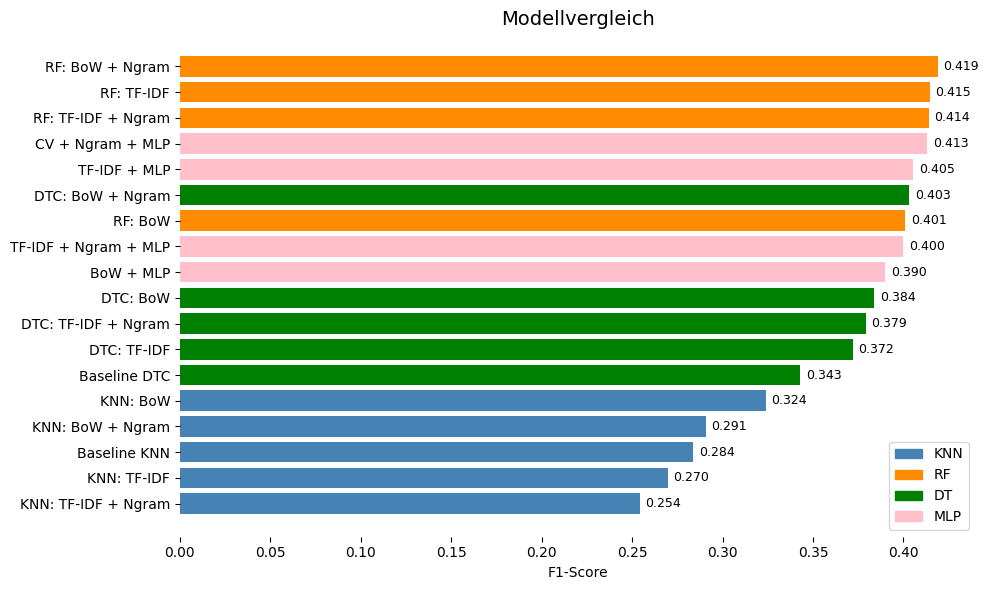

In [100]:
results_df = pd.Series({k: v[0] for k, v in results.items()}).sort_values()
color_map = {"KNN": "steelblue", "RF": "darkorange", "DT": "green", "MLP" : "pink"}
colors = [next(c for k, c in color_map.items() if k in name) for name in results_df.index]

_, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(results_df.index, results_df.values, color=colors)
ax.set_title("Modellvergleich", fontsize=14)
ax.set_xlabel("F1-Score")
ax.bar_label(bars, fmt="{:.3f}", padding=4, fontsize=9)
ax.spines[:].set_visible(False)

ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()], loc="lower right")

plt.tight_layout()
plt.show()

### 7.1.4 Testen des besten Modells

Was ist Unterschied zwischen Testen und Stichprobe? Ein Tweet richtig/falsch zugeordnet und erläutern

Bestes Modell: RF: BoW + Ngram
              precision    recall  f1-score   support

   happiness       0.43      0.40      0.42       544
        love       0.47      0.42      0.44       550
     neutral       0.37      0.49      0.42       601
     sadness       0.45      0.40      0.42       607
       worry       0.30      0.29      0.29       525

    accuracy                           0.40      2827
   macro avg       0.41      0.40      0.40      2827
weighted avg       0.41      0.40      0.40      2827



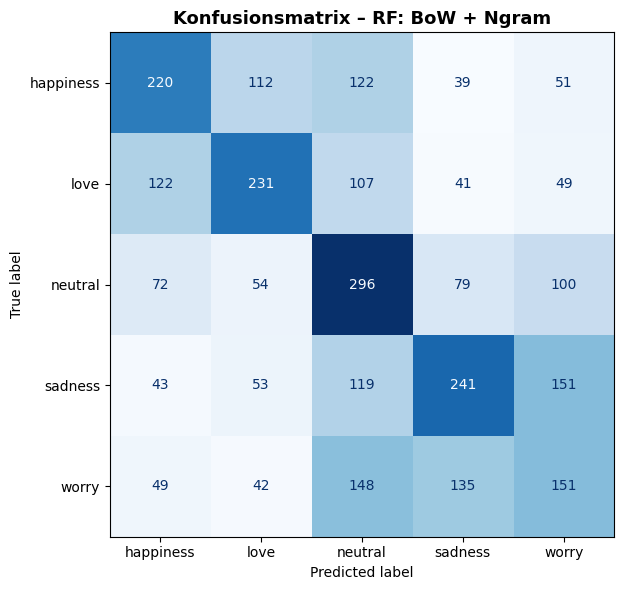

In [101]:
best_name   = results_df.index[-1]
best_model  = results[best_name][1]
y_pred_best = best_model.predict(results[best_name][4])

print(f"Bestes Modell: {best_name}")
print(classification_report(y_test, y_pred_best, zero_division=0))

_, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Konfusionsmatrix – {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.1.6 Trainings und Validierungmetriken (Overfitting?)

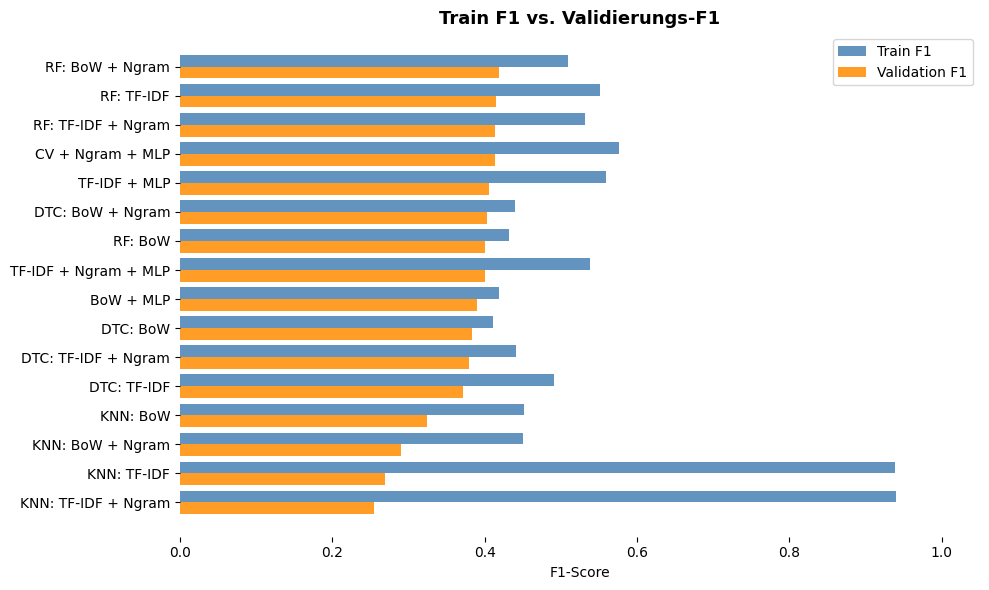

In [102]:
# Baseline-Modelle (Cell 44) nutzen einen anderen Split (y_raw_train) und
# koennen hier nicht mit dem gemeinsamen y_train verglichen werden.
names = [n for n in results_df.index if not n.startswith("Baseline")]
f1_tr = [f1_score(y_train, results[n][1].predict(results[n][2]), average="macro") for n in names]
f1_val = [results[n][0] for n in names]

_, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(names))

ax.barh(x+0.2, f1_tr, 0.4, label="Train F1", color="steelblue", alpha=0.85)
ax.barh(x-0.2, f1_val, 0.4, label="Validation F1", color="darkorange", alpha=0.85)
ax.set(yticks=x, yticklabels=names, xlabel="F1-Score", xlim=(0, 1.05))
ax.set_title("Train F1 vs. Validierungs-F1", fontsize=13, fontweight="bold")
ax.legend()
ax.spines[:].set_visible(False)

plt.tight_layout()
plt.show()

TODO: Die oben gezeigte Grafik verdeutlicht...